In [1]:
import os
import math
import json
import warnings
import itertools

warnings.filterwarnings("ignore")

In [2]:
os.environ.setdefault("FINTORCH_BASE_TIME_FRAME", "60")

'60'

In [3]:
import numpy as np 
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from fintorch.enum import TimeFrame
from fintorch.exchange import ONLINE_EXCHANGE
from fintorch.utils.preprocess import remove_price_dependency
from fintorch.utils.args import DefaultArgumentParser
from fintorch.utils.plot import draw_candlestick_plot, draw_labels, draw_predictions

In [4]:
string_args = [
    "--start-date", "2024-01-01",
    "--stop-date", "2024-06-01",
    "--time-frame", "60",
    "--symbol", "BTC-USDT"
]

args = DefaultArgumentParser.parse(args=string_args)

In [5]:
sdf = ONLINE_EXCHANGE.future.data.get_candles_dataframe(symbol=args.symbol, time_frame=args.time_frame).copy()

sdf

,open,high,low,close,volume,trade
timestamp,,,,,,
1705395660,43032.7,43040.0,42985.6,43003.7,201.772,3323
1705395720,43004.5,43016.0,42960.0,42967.3,534.556,4093
1705395780,42967.3,42976.5,42954.2,42957.8,117.148,1847
1705395840,42957.9,42965.7,42928.9,42942.2,245.105,3502
1705395900,42942.3,42953.0,42919.0,42942.6,134.988,1928
...,...,...,...,...,...,...
1711406100,70419.7,70438.9,70406.9,70438.8,79.550,1522
1711406160,70438.7,70524.7,70438.7,70510.3,134.209,2770
1711406220,70510.3,70510.4,70437.2,70464.4,78.321,1687


In [169]:
df = remove_price_dependency(df=sdf.copy())[:1000]
df["roc"] = df.close - df.open
df["cmax"] = df.high.rolling(window=21, center=True).max()
df["cmin"] = df.close.rolling(window=21, center=True).min()
df["fractal"] = (df.high == df.cmax)
df = np.round(df, 6)
df = df.dropna()

df

,open,high,low,close,volume,trade,roc,cmax,cmin,fractal
timestamp,,,,,,,,,,
1705396320,-0.001938,-0.001835,-0.002459,-0.001966,100.250,1747,-0.000028,0.002414,-0.003030,False
1705396380,-0.001966,-0.001966,-0.002520,-0.002466,46.979,1289,-0.000501,0.003047,-0.003030,False
1705396440,-0.002466,-0.002194,-0.003121,-0.003030,249.853,2298,-0.000564,0.003047,-0.003030,False
1705396500,-0.003030,-0.002471,-0.003030,-0.002683,52.615,1042,0.000347,0.003047,-0.003030,False
1705396560,-0.002683,-0.001933,-0.002683,-0.002119,55.875,1175,0.000564,0.003047,-0.003030,False
...,...,...,...,...,...,...,...,...,...,...
1705454760,0.004072,0.004074,0.003481,0.003669,164.773,1455,-0.000403,0.004127,0.001384,False
1705454820,0.003669,0.004120,0.003530,0.004016,65.320,1189,0.000347,0.004127,0.001384,False
1705454880,0.004016,0.004102,0.003831,0.003984,74.212,972,-0.000032,0.004127,0.001384,False


In [167]:
points = [(index, df.close.iloc[index]) for index in range(len(df)) if df.fractal.iloc[index]]

a = -0.00001
b_values = []
for x, y in tqdm(points):
    b = round(y - a * x, 6)
    b_values.append(b)

# b_values = list(set(np.round(b_values, 3)))

  0%|          | 0/3 [00:00<?, ?it/s]

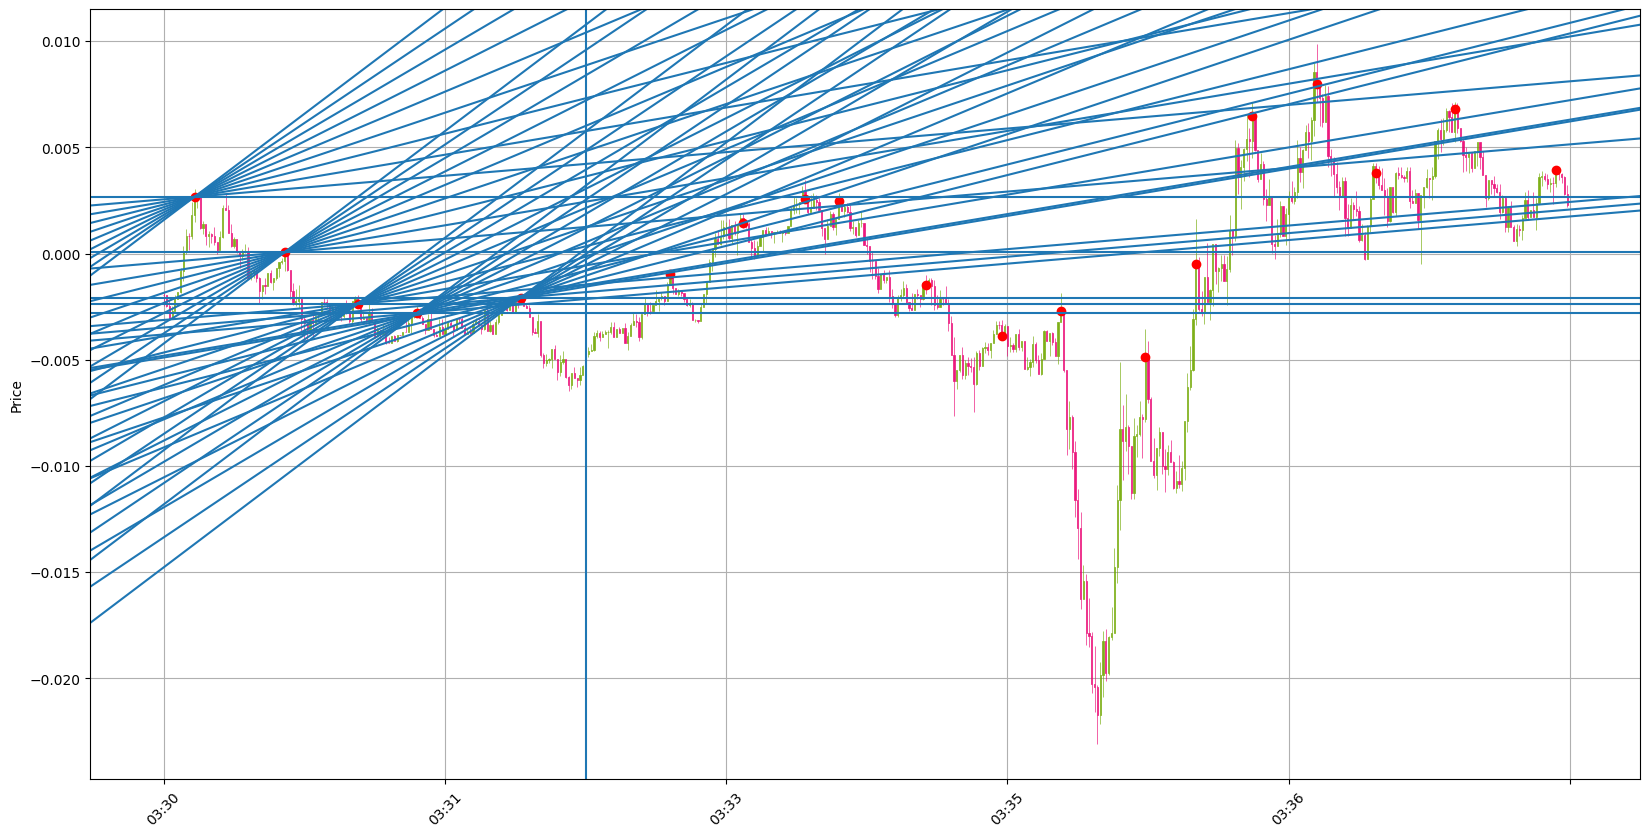

In [187]:
test_index = 150
pdf = df.copy()[:500]
pdf = pdf.reset_index()

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 10))

draw_candlestick_plot(ax=ax, df=pdf)
ax.plot(pdf.close[pdf.fractal], "ro")
ax.axvline(test_index)

for slope in np.linspace(0, 0.0001, 10):
    for index in range(test_index):
        if df.fractal.iloc[index]:
            xy1 = (index, df.close.iloc[index])
            ax.axline(xy1=xy1, slope=slope)
    
ax.grid()